# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Date_Analysis/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
monthly_rent = df['count'].resample('ME').mean()

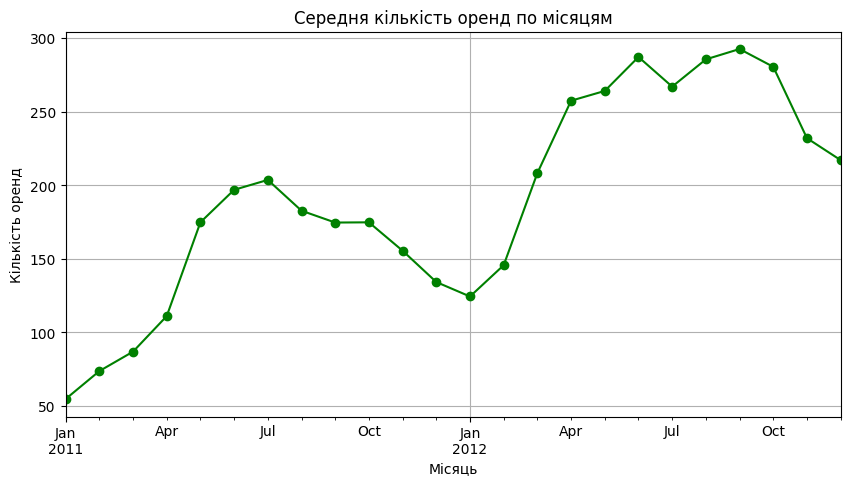

In [4]:
# Pandas

monthly_rent.plot(
    figsize=(10,5),
    marker='o',
    color='green',
    xlabel='Місяць',
    ylabel='Кількість оренд',
    title='Середня кількість оренд по місяцям',
    grid=True
);

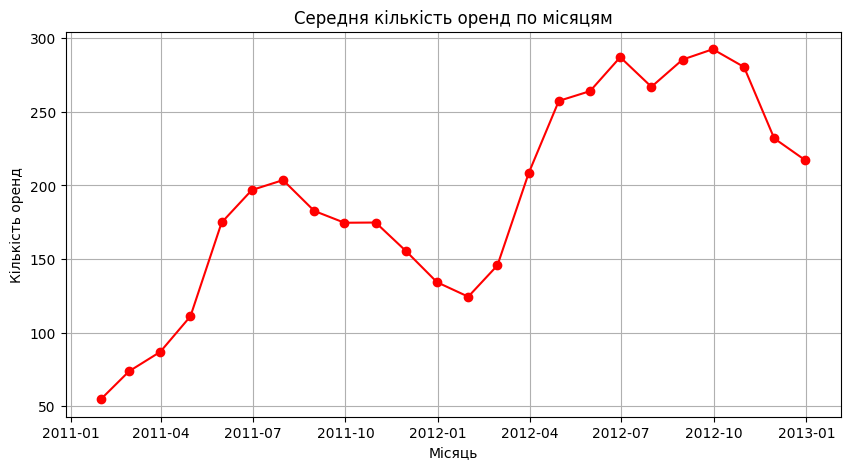

In [5]:
# Matplotlib
plt.figure(figsize=(10,5))
plt.plot(monthly_rent, 'o-r')
plt.title('Середня кількість оренд по місяцям')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.grid(True);

Чим відрізняються графіки:
- сіткою - в графіку, побудованому за допомою pandas, горизонтальні лінії і лише одна вертикальна , яка показує відлік нового року, а в другому, побудованому за допомогою matplotlib, сітка складається з горизонтальних та вертикальних ліній.
- вісю Х (дати відображаються по різному) - в першому варінті дати відображаються по місяцям, а в другому у форматі рік-місяць.
- початок та кінець лінії на графіку - в першому варінті від початку до кінця, без відступів, у другому ж варінті відступи є.
Особисто мені, більше до вподоби графік побудований за допомогою бібліотеки pandas, якщо не потрібно додаткових налаштувань і потрібен швидкий результат, це оптимальний варіант.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [6]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

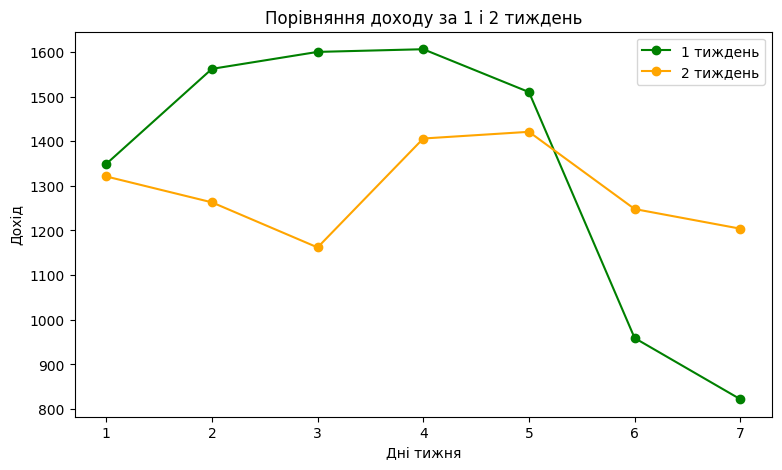

In [7]:
plt.figure(figsize=(9,5))
plt.plot(days, sales_week1, label='1 тиждень', color='green', marker='o')
plt.plot(days, sales_week2, label='2 тиждень', color='orange', marker='o')
plt.legend()
plt.title('Порівняння доходу за 1 і 2 тиждень')
plt.xlabel('Дні тижня')
plt.ylabel('Дохід');

1. В другий тиждень більш стабільні продажі.
2. Можна обчислити мінімум, максимум, розмах та стандартне відхілення.

In [8]:
print (f'Статистика по 1 тижню: мінімум - {min(sales_week1)}, максимум - {max(sales_week1)}, розмах - {max(sales_week1) - min(sales_week1)}, стандартне відхилення - {np.std(sales_week1):.2f}')
print (f'Статистика по 2 тижню: мінімум - {min(sales_week2)}, максимум - {max(sales_week2)}, розмах - {max(sales_week2) - min(sales_week2)}, стандартне відхилення - {np.std(sales_week2):.2f}')

Статистика по 1 тижню: мінімум - 822, максимум - 1606, розмах - 784, стандартне відхилення - 300.00
Статистика по 2 тижню: мінімум - 1162, максимум - 1421, розмах - 259, стандартне відхилення - 90.91


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [9]:
# Підготовка необхідних даних

monthly_temp = df['temp'].resample('ME').mean()
avg_rent = df.groupby('season')['count'].mean()

In [10]:
import matplotlib.dates as mdates

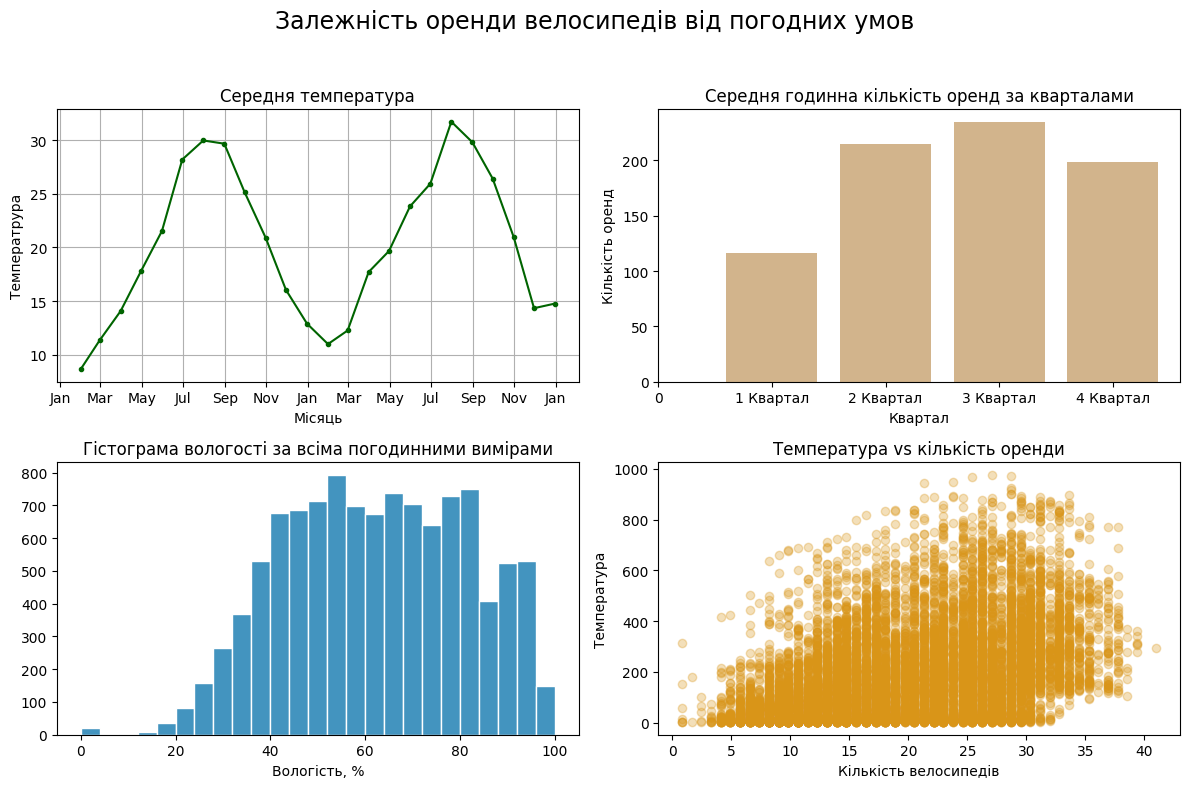

In [11]:
plt.figure(figsize=(12,8))

#1 Лінійний графік середньої температури помісячно.
plt.subplot(2, 2, 1)
plt.plot(monthly_temp, color='darkgreen',marker='.')
plt.title('Середня температура')
plt.xlabel('Місяць')
plt.ylabel('Температрура')
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))


#2 Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
plt.subplot(2, 2, 2)
plt.bar(avg_rent.index, avg_rent.values, color='tan')
plt.title('Cередня годинна кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')

quart = ['0', '1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал']
plt.xticks(range(5), quart)

#3 Гістограма вологості за всіма погодинними вимірами.
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=25, color='#4394bf', edgecolor="white")
plt.title('Гістограма вологості за всіма погодинними вимірами')
plt.xlabel('Вологість, %')


#4 Scatter plot температури vs кількості оренд.
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], color='#d99518', alpha=0.3)
plt.title('Температура vs кількість оренди')
plt.xlabel('Кількість велосипедів')
plt.ylabel('Температура')


plt.suptitle('Залежність оренди велосипедів від погодних умов', fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

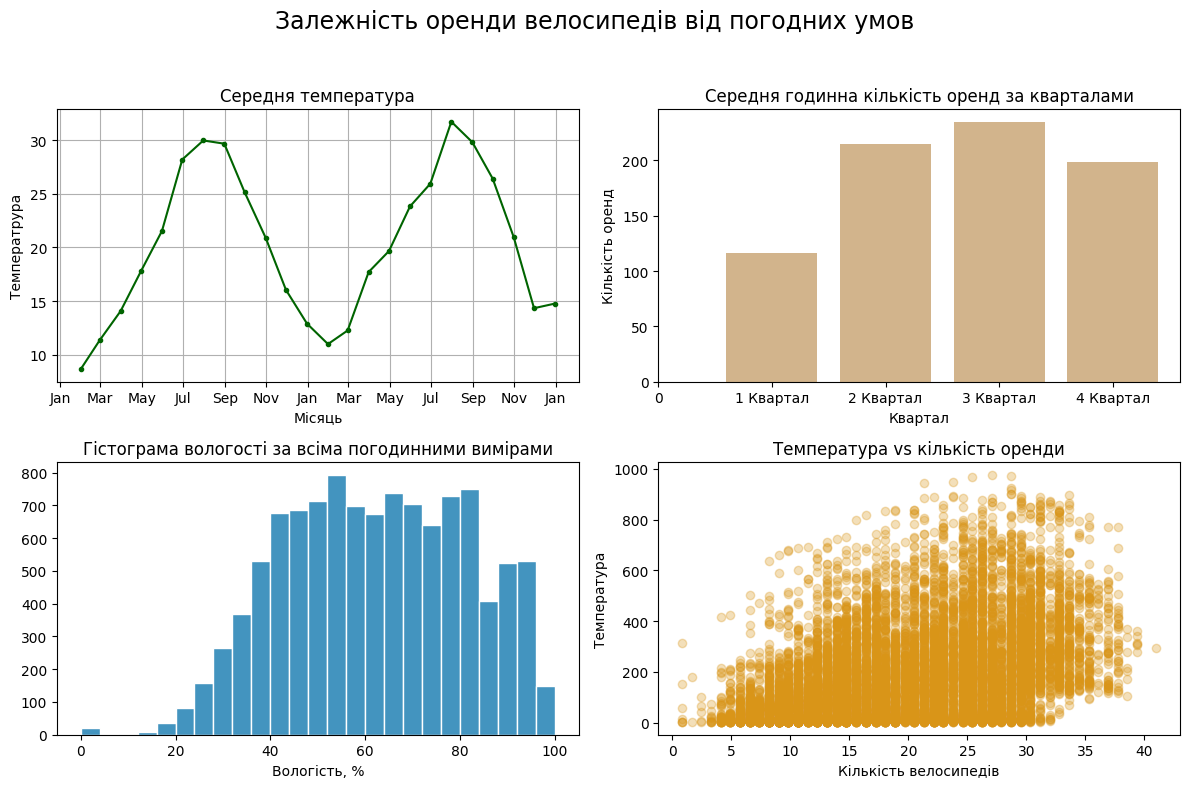

In [12]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

#1 Лінійний графік середньої температури помісячно.

ax[0, 0].plot(monthly_temp, color='darkgreen', marker='.')
ax[0, 0].set_title('Середня температура')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температрура')
ax[0, 0].grid(True)

ax[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))


#2 Стовпчикова діаграма середньої годинної кількості оренд за кварталами.

ax[0, 1].bar(avg_rent.index, avg_rent.values, color='tan')
ax[0, 1].set_title('Cередня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Кількість оренд')

quart = ['0', '1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал']
ax[0, 1].set_xticks(range(5))
ax[0, 1].set_xticklabels(quart)


#3 Гістограма вологості за всіма погодинними вимірами.

ax[1, 0].hist(df['humidity'], bins=25,color='#4394bf', edgecolor='white')
ax[1, 0].set_title('Гістограма вологості за всіма погодинними вимірами')
ax[1, 0].set_xlabel('Вологість, %')


#4 Scatter plot температури vs кількості оренд.

ax[1, 1].scatter(df['temp'], df['count'], color='#d99518', alpha=0.3)
ax[1, 1].set_title('Температура vs кількість оренди')
ax[1, 1].set_xlabel('Кількість велосипедів')
ax[1, 1].set_ylabel('Температура')


fig.suptitle('Залежність оренди велосипедів від погодних умов', fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


 У підході `plt.subplot()` потрібно кожну дію прописувати починаючи з plt.
 та на початку роботи з кожним графіком на дашборді потрібно виділяти його таким чином plt.subplot(..), вказуючи при цьомув дужках, в якій колонці, в якому рядку та на якій позиції він знаходиться, а в підході `plt.subplots()` один раз на початку задаємо полотно та розмір сітки, і далі просто звертаємося до необхіднлої нам axes, що є більш зручним.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [13]:
monthly_stats = df['count']. resample('ME').agg(['mean', 'max', 'min'])

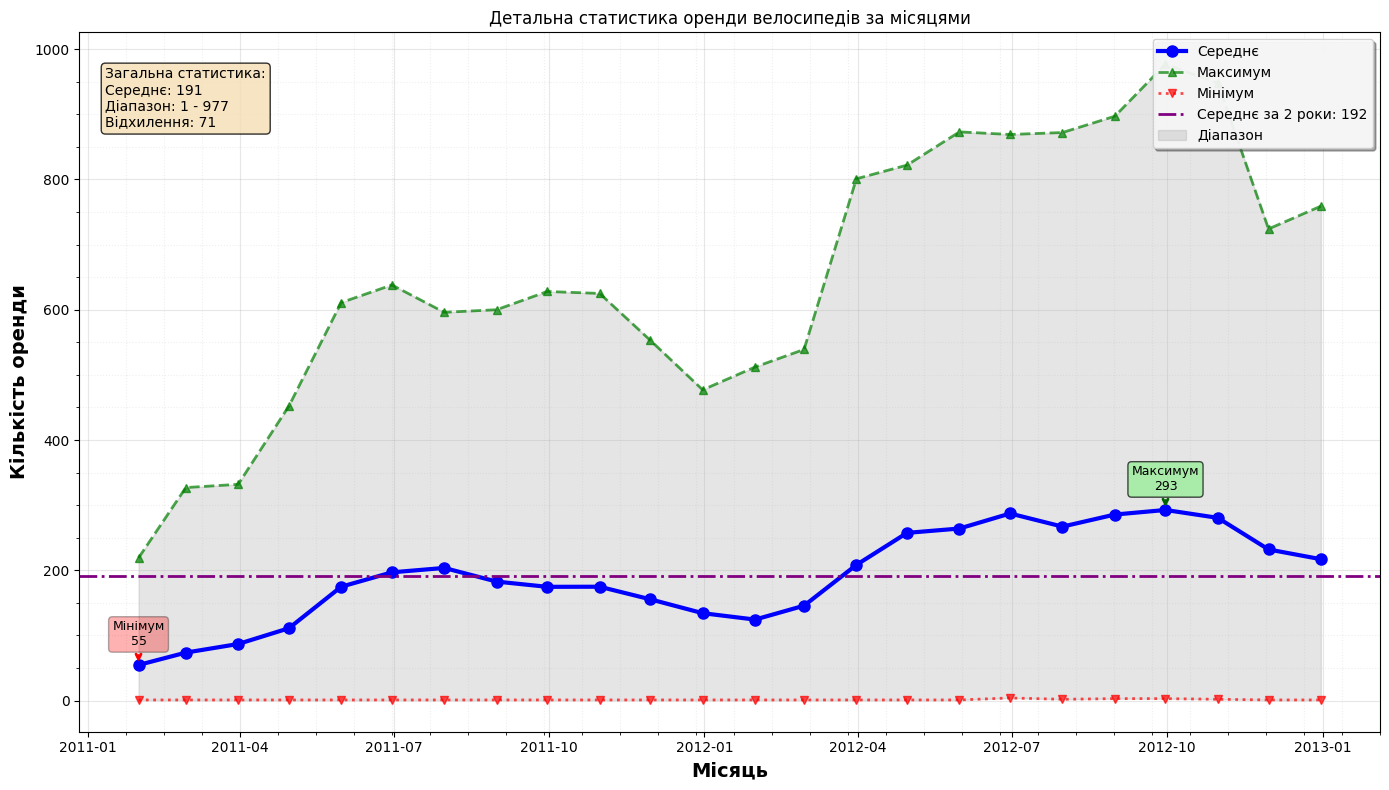

In [41]:
fig, ax = plt.subplots(figsize=(14,8))

# Основні лінії
ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Середня лінія за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за 2 роки: {overall_mean:.0f}')


# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів за місяцями')


# Заливка між max та min
ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')


# Сітка
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()


# Текст з додатковою статистикою
textstr = 'Загальна статистика:\n'
textstr += f'Середнє: {monthly_stats["mean"].mean():.0f}\n'
textstr += f'Діапазон: {monthly_stats['min'].min()} - {monthly_stats['max'].max()}\n'
textstr += f'Відхилення: {monthly_stats["mean"].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)


#Анотації для макс і мін значень
max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Maксимум\n{max_val:.0f}',
            xy = (max_idx, max_val), xytext=(max_idx, max_val + 30),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Mінімум\n{min_val:.0f}',
            xy = (min_idx, min_val), xytext=(min_idx, min_val + 30),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3))


# Легенда
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.show()

1. Для людини яка не дуже розумієтьс в даних, зображені на графіку анотації, працюють як підказки, одразу виділено найголовніші моменти візуалізації.
2. У нашому графіку, для того, щоб наглядно виділити область від мінімальних до максимальних значень.
3. Текстовий блок дає загальне уявлення про дані, завдяки основним статистичним показникам представленим на ньому.